# Final Gemma 4

In [10]:
import polars as pl

from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.wasserstein_distance import (
    calculate_wasserstein_distance,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
import social_groups.polars_columns as plc
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

In [11]:
parser = AnswerParser(AnswerOptions.letters_A_to_D)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_D, triple_underscore_handling="wrong"
)

In [12]:
from social_groups.analysis.definitions import defs

gemma4_single_model_baseline: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_single_model_baseline"
)
gemma4_no_discussion_voting: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_no_discussion_voting_base"
)
gemma4_multi_agent_debate: pl.DataFrame = defs().load_asset_value(
    "final_gemma4_multi_agent_debateV2"
)

2026-07-11 12:01:43 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_single_model_baseline.parquet using PolarsParquetIOManager...
2026-07-11 12:01:43 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_no_discussion_voting_base.parquet using PolarsParquetIOManager...
2026-07-11 12:01:44 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_gemma4_multi_agent_debateV2.parquet using PolarsParquetIOManager...


In [13]:
gemma4_multi_agent_debate = apply_parsing_and_group_decision(
    gemma4_multi_agent_debate, parser, comparer, group_reply
)
gemma4_no_discussion_voting = gemma4_no_discussion_voting.with_columns(
    parser(pl.col(plc.final_answer)).alias("parsed_answer")
).drop(
    "phoenix_span_url",
    "run_identifier",
    "question_id",
    "category",
    "question",
    "with_few_shot_prompting",
    "use_thinking",
    "max_new_tokens",
    "final_answer",
    "temperature",
    "top_p",
    "model_name",
)

gemma4_single_model_baseline = (
    gemma4_single_model_baseline.with_columns(
        parser(pl.col(plc.final_answer)).alias("parsed_answer")
    )
    .with_columns(
        comparer(pl.col("parsed_answer"), pl.col(plc.answer_string)).alias(
            plc.is_correct
        )
    )
    .drop(
        "phoenix_span_url",
        "run_identifier",
        "final_answer",
        "question_id",
        "category",
        "question",
        "with_few_shot_prompting",
        "use_thinking",
        "max_new_tokens",
        "temperature",
        "top_p",
        "model_name",
    )
)

In [14]:
single_model_result = gemma4_single_model_baseline.group_by("seed", "model_size").agg(
    pl.col("used_input_tokens").mean(),
    pl.col("used_output_tokens").mean(),
    accuracy=pl.col("is_correct").mean(),
)
single_model_result

seed,model_size,used_input_tokens,used_output_tokens,accuracy
i64,str,f64,f64,f64
3,"""E4B""",245.045455,1681.636364,0.535354
2,"""31B""",249.045455,744.722222,0.762626
1,"""31B""",249.045455,772.757576,0.762626
4,"""E4B""",245.045455,1738.19697,0.545455
4,"""E2B""",245.045455,1530.631313,0.40404
…,…,…,…,…
2,"""E4B""",245.045455,1649.707071,0.570707
2,"""E2B""",245.045455,1516.712121,0.39899
5,"""E4B""",245.045455,1735.383838,0.510101


In [15]:
import polars as pl


no_discussion_result = (
    gemma4_no_discussion_voting.group_by("seed", "model_size", "original_question_id")
    .agg(
        pl.col("answer_string").unique().item(),
        pl.col("parsed_answer").alias("parsed_answers"),
        pl.col("used_input_tokens").alias("used_input_tokensS"),
        pl.col("used_output_tokens").alias("used_output_tokensS"),
    )
    .join(
        pl.DataFrame({"no_participants": range(1, 10)}),
        how="cross",
    )
    .with_columns(
        group_answer=group_reply(
            pl.col("parsed_answers").list.slice(0, pl.col("no_participants"))
        ),
        used_input_tokens=pl.col("used_input_tokensS")
        .list.slice(0, pl.col("no_participants"))
        .list.sum(),
        used_output_tokens=pl.col("used_output_tokensS")
        .list.slice(0, pl.col("no_participants"))
        .list.sum(),
    )
    .with_columns(is_correct=comparer(pl.col("group_answer"), pl.col("answer_string")))
    .group_by("seed", "model_size", "no_participants")
    .agg(
        pl.col("used_input_tokens").mean(),
        pl.col("used_output_tokens").mean(),
        accuracy=pl.col("is_correct").mean(),
    )
)

no_discussion_result

seed,model_size,no_participants,used_input_tokens,used_output_tokens,accuracy
i64,str,i64,f64,f64,f64
3,"""E2B""",9,2205.409091,13774.843434,0.414141
5,"""E2B""",4,980.181818,6132.39899,0.348485
2,"""E2B""",5,1225.227273,7550.909091,0.39899
2,"""E2B""",2,490.090909,2993.944444,0.313131
5,"""E4B""",1,245.045455,1761.116162,0.555556
…,…,…,…,…,…
5,"""E4B""",4,980.181818,7027.656566,0.545455
5,"""E4B""",3,735.136364,5280.838384,0.550505
3,"""E2B""",6,1470.272727,9141.555556,0.393939


In [38]:
mad_result = (
    gemma4_multi_agent_debate.drop(
        [
            "question_id",
            "category",
            "with_few_shot_prompting",
            "max_new_tokens",
            "top_p",
            "temperature",
            "model_names",
        ]
    )
    .group_by("seed", "model_sizes", "group_constellation", "thinking_openly")
    .agg(
        comparer(pl.col(plc.parsed_combined_answers_before), pl.col(plc.answer_string))
        .mean()
        .alias("accuracy_before"),
        comparer(pl.col(plc.parsed_combined_answers_after), pl.col(plc.answer_string))
        .mean()
        .alias("accuracy"),
        pl.col("used_input_tokens").mean(),
        pl.col("used_output_tokens").mean(),
        pl.col("run_identifier").implode().list.eval(pl.element().str.split("_").list.last().cast(pl.Int64)).list.min(),
        pl.col("phoenix_span_url").first()
    )
    .with_columns(accuracy_increase=pl.col("accuracy") - pl.col("accuracy_before"))
)

In [18]:
(
    single_model_result.group_by("model_size").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
    )
)

model_size,used_input_tokens_mean,used_output_tokens_mean,accuracy_mean,used_input_tokens_std,used_output_tokens_std,accuracy_std
str,f64,f64,f64,f64,f64,f64
"""E2B""",245.045455,1528.938384,0.39596,0.0,16.070207,0.021007
"""31B""",249.045455,757.274747,0.766667,0.0,11.373146,0.009715
"""E4B""",245.045455,1703.159596,0.540404,0.0,37.569766,0.021723


In [19]:
(
    no_discussion_result.group_by("model_size", "no_participants").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
    )
)

model_size,no_participants,used_input_tokens_mean,used_output_tokens_mean,accuracy_mean,used_input_tokens_std,used_output_tokens_std,accuracy_std
str,i64,f64,f64,f64,f64,f64,f64
"""E4B""",5,1225.227273,8617.618182,0.541414,0.0,187.731141,0.014015
"""E4B""",7,1715.318182,12089.737374,0.556566,0.0,242.423728,0.016902
"""E2B""",7,1715.318182,10650.777778,0.393939,0.0,84.085745,0.007142
"""E4B""",6,1470.272727,10352.70202,0.529293,0.0,214.833293,0.017275
"""E2B""",3,735.136364,4550.3,0.378788,0.0,39.825204,0.014725
…,…,…,…,…,…,…,…
"""E4B""",3,735.136364,5163.533333,0.553535,0.0,109.370482,0.019099
"""E2B""",5,1225.227273,7580.511111,0.389899,0.0,41.576462,0.014015
"""E4B""",1,245.045455,1713.829293,0.558586,0.0,40.732903,0.022473


In [39]:
(
    mad_result.group_by("group_constellation", "thinking_openly").agg(
        pl.exclude("seed").mean().name.suffix("_mean"),
        pl.exclude("seed").std().name.suffix("_std"),
        pl.col("run_identifier").min(),
        pl.col("phoenix_span_url").first()
    )
)

group_constellation,thinking_openly,model_sizes_mean,accuracy_before_mean,accuracy_mean,used_input_tokens_mean,used_output_tokens_mean,run_identifier_mean,phoenix_span_url_mean,accuracy_increase_mean,model_sizes_std,accuracy_before_std,accuracy_std,used_input_tokens_std,used_output_tokens_std,run_identifier_std,phoenix_span_url_std,accuracy_increase_std,run_identifier,phoenix_span_url
str,str,list[str],f64,f64,f64,f64,f64,str,f64,list[str],f64,f64,f64,f64,f64,str,f64,i64,str
"""HHL""","""only_H""",null,0.522222,0.562626,28705.693939,10139.519192,78.0,null,0.040404,null,0.016209,0.023309,347.318588,148.228593,44.271887,null,0.014725,22,"""http://localhost:46001/project…"
"""HH""","""only_H""",null,0.448485,0.541414,18653.454545,6820.572727,46.0,null,0.092929,null,0.016902,0.006585,288.647594,113.659553,25.298221,null,0.01317,14,"""http://localhost:46001/project…"
"""LL""","""only_H""",null,0.292929,0.362626,7320.947475,6378.319192,34.0,null,0.069697,null,0.017495,0.026581,82.543295,111.462295,25.298221,null,0.018349,2,"""http://localhost:46001/project…"
"""HHL""","""all""",null,0.516162,0.560606,35375.221212,10056.642424,79.0,null,0.044444,null,0.02682,0.018557,391.440174,194.270661,44.271887,null,0.022978,23,"""http://localhost:46001/project…"
"""LHH""","""nobody""",null,0.50202,0.537374,11844.705051,10539.537374,68.0,null,0.035354,null,0.009175,0.015402,120.028093,154.360246,44.271887,null,0.010101,12,"""http://localhost:46001/project…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""LHH""","""all""",null,0.494949,0.553535,34482.372727,9717.334343,71.0,null,0.058586,null,0.021723,0.01455,193.2759,97.260041,44.271887,null,0.026146,15,"""http://localhost:46001/project…"
"""HH""","""nobody""",null,0.439394,0.518182,8064.783838,7219.591919,44.0,null,0.078788,null,0.010101,0.015402,78.466978,90.569003,25.298221,null,0.017713,12,"""http://localhost:46001/project…"
"""HL""","""only_L""",null,0.315152,0.462626,12509.591919,6719.59697,41.0,null,0.147475,null,0.009845,0.016209,162.676835,144.726968,25.298221,null,0.015319,9,"""http://localhost:46001/project…"


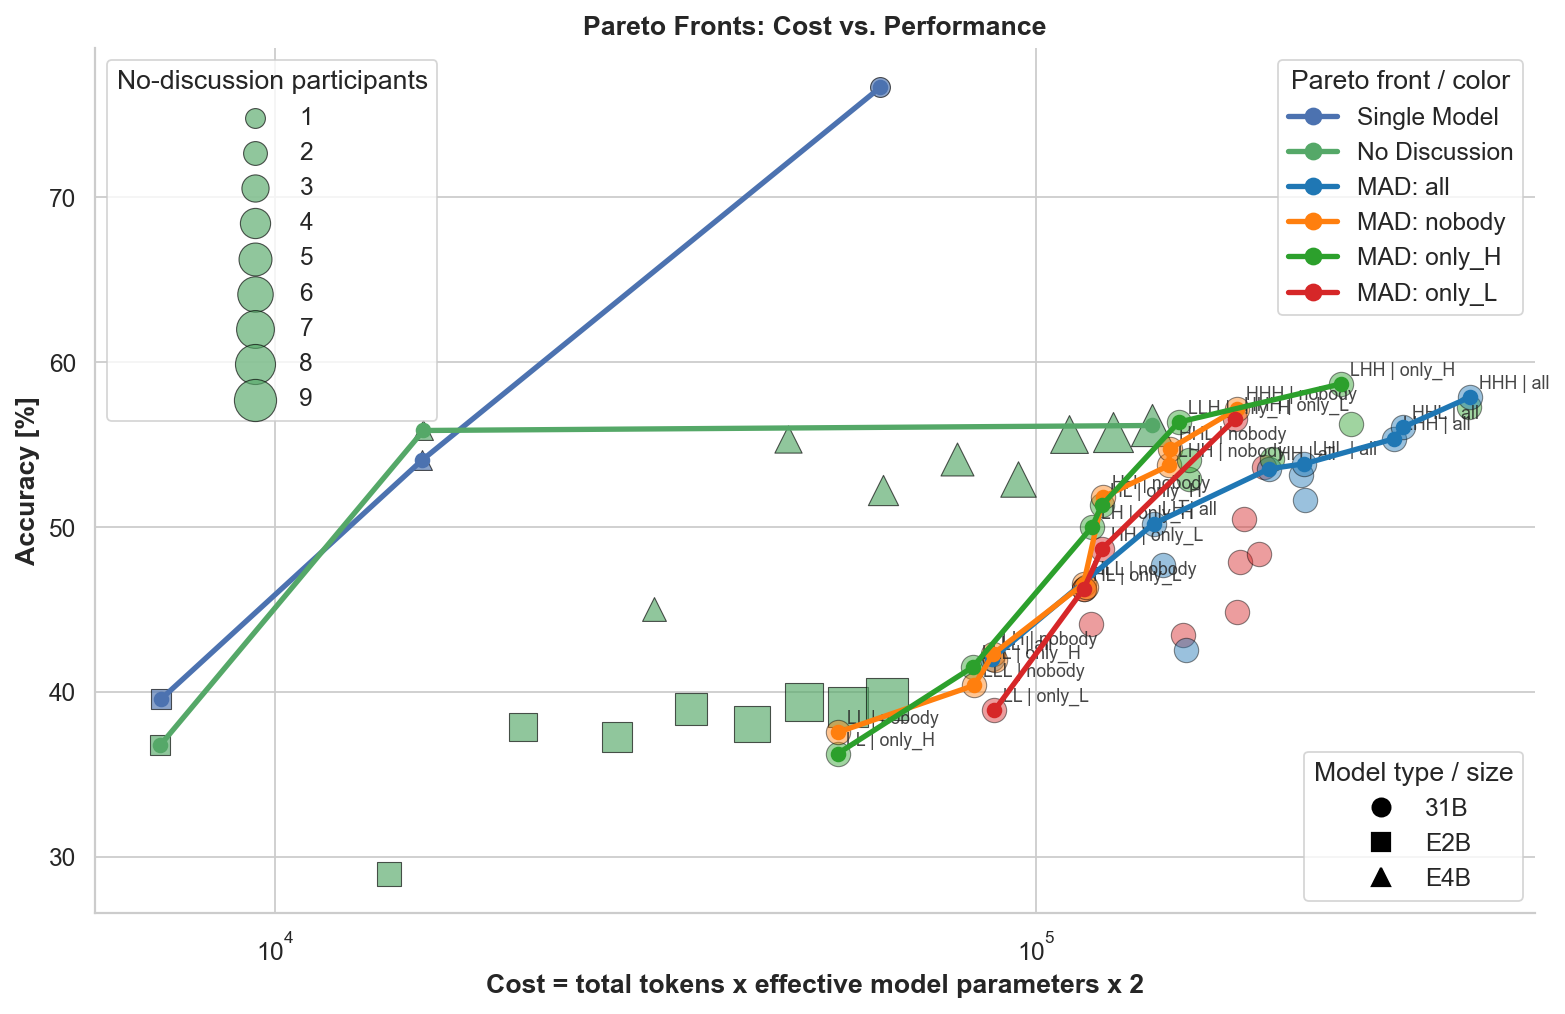

In [42]:
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.25,
    rc={
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "legend.frameon": True,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    },
)

PARAMS_BILLIONS = {
    "E2B": 2,
    "E4B": 4,
    "31B": 31,
}

METHOD_ORDER = [
    "Single Model",
    "No Discussion",
    "MAD",
]

BASE_METHOD_COLORS = {
    "Single Model": "#4C72B0",
    "No Discussion": "#55A868",
}

MARKERS = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]


def extract_model_sizes(value):
    if isinstance(value, (list, tuple)):
        raw = " ".join(map(str, value))
    else:
        raw = str(value)

    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, (list, tuple)):
            raw = " ".join(map(str, parsed))
    except Exception:
        pass

    models = re.findall(r"(E2B|E4B|31B)", raw)

    if not models:
        raise ValueError(f"Could not infer model size from: {value}")

    return models


def model_params_sum(value):
    return sum(PARAMS_BILLIONS[m] for m in extract_model_sizes(value))


def model_params_average(value):
    return np.mean([PARAMS_BILLIONS[m] for m in extract_model_sizes(value)])


def bootstrap_ci(values, statistic=np.mean, n_boot=5000, ci=95, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan

    if len(values) == 1:
        stat = statistic(values)
        return stat, stat

    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    stats = np.apply_along_axis(statistic, 1, samples)

    alpha = (100 - ci) / 2
    return np.percentile(stats, alpha), np.percentile(stats, 100 - alpha)


def to_pandas(df):
    return df.to_pandas() if isinstance(df, pl.DataFrame) else df.copy()


def model_shape_key(frame):
    if "model_type" in frame.columns and "model_size" in frame.columns:
        return frame["model_type"].astype(str) + " " + frame["model_size"].astype(str)
    if "model_size" in frame.columns:
        return frame["model_size"].astype(str)
    if "model_sizes" in frame.columns:
        return frame["model_sizes"].astype(str)
    return "model"


def prepare_pareto_results(
    mad_result,
    no_discussion_result,
    single_model_result,
):
    single = to_pandas(single_model_result)
    single["method"] = "Single Model"
    single["setting"] = model_shape_key(single)
    single["shape_key"] = model_shape_key(single)
    single["thinking_openly"] = "Single Model"
    single["no_participants"] = 1
    single["effective_params_b"] = single["model_size"].apply(model_params_sum)

    nodisc = to_pandas(no_discussion_result)
    nodisc["method"] = "No Discussion"
    nodisc["shape_key"] = model_shape_key(nodisc)
    nodisc["setting"] = (
        nodisc["shape_key"].astype(str)
        + " x "
        + nodisc["no_participants"].astype(str)
    )
    nodisc["thinking_openly"] = "No Discussion"
    nodisc["effective_params_b"] = nodisc["model_size"].apply(model_params_sum)

    mad = to_pandas(mad_result)
    mad["method"] = "MAD"
    mad["setting"] = (
        mad["group_constellation"].astype(str)
        + " | "
        + mad["thinking_openly"].astype(str)
    )
    mad["shape_key"] = "MAD"
    mad["no_participants"] = np.nan
    mad["effective_params_b"] = mad["model_sizes"].apply(model_params_average)

    common_cols = [
        "seed",
        "method",
        "setting",
        "shape_key",
        "thinking_openly",
        "no_participants",
        "accuracy",
        "used_input_tokens",
        "used_output_tokens",
        "effective_params_b",
    ]

    df = pd.concat(
        [
            single[common_cols],
            nodisc[common_cols],
            mad[common_cols],
        ],
        ignore_index=True,
    )

    df["total_tokens"] = df["used_input_tokens"] + df["used_output_tokens"]
    df["cost"] = df["total_tokens"] * df["effective_params_b"] * 2
    df["accuracy_pct"] = 100 * df["accuracy"]

    return df


def aggregate_for_pareto_plotting(df, n_boot=5000):
    rows = []

    group_cols = [
        "method",
        "setting",
        "shape_key",
        "thinking_openly",
        "no_participants",
    ]

    for keys, part in df.groupby(group_cols, dropna=False):
        method, setting, shape_key, thinking_openly, no_participants = keys

        acc_low, acc_high = bootstrap_ci(
            part["accuracy_pct"],
            n_boot=n_boot,
        )

        cost_low, cost_high = bootstrap_ci(
            part["cost"],
            n_boot=n_boot,
        )

        rows.append(
            {
                "method": method,
                "setting": setting,
                "shape_key": shape_key,
                "thinking_openly": thinking_openly,
                "no_participants": no_participants,
                "accuracy_mean": part["accuracy"].mean(),
                "accuracy_pct_mean": part["accuracy_pct"].mean(),
                "accuracy_pct_low": acc_low,
                "accuracy_pct_high": acc_high,
                "cost_mean": part["cost"].mean(),
                "cost_low": cost_low,
                "cost_high": cost_high,
                "total_tokens_mean": part["total_tokens"].mean(),
                "effective_params_b_mean": part["effective_params_b"].mean(),
                "n_seeds": part["seed"].nunique(),
            }
        )

    agg = pd.DataFrame(rows)
    agg["method"] = pd.Categorical(
        agg["method"],
        categories=METHOD_ORDER,
        ordered=True,
    )

    return agg.sort_values(["method", "cost_mean"])


def pareto_front(df, cost_col="cost_mean", perf_col="accuracy_pct_mean"):
    d = df.sort_values([cost_col, perf_col], ascending=[True, False]).copy()

    best_so_far = -np.inf
    keep = []

    for _, row in d.iterrows():
        if row[perf_col] > best_so_far:
            keep.append(True)
            best_so_far = row[perf_col]
        else:
            keep.append(False)

    return d.loc[keep].copy()


def marker_size_from_participants(value, min_size=80, max_size=260):
    if pd.isna(value):
        return 120

    value = float(value)
    return min_size + (value - 1) * 35


def add_mad_labels(ax, data, fontsize=8):
    for _, r in data.iterrows():
        ax.annotate(
            str(r["setting"]),
            xy=(r["cost_mean"], r["accuracy_pct_mean"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=fontsize,
            alpha=0.85,
        )


def plot_pareto_fronts_new(
    mad_result,
    no_discussion_result,
    single_model_result,
    save_path=None,
    label_mad_points=True,
):
    df = prepare_pareto_results(
        mad_result=mad_result,
        no_discussion_result=no_discussion_result,
        single_model_result=single_model_result,
    )

    agg = aggregate_for_pareto_plotting(df)

    mad_values = sorted(
        agg.loc[agg["method"] == "MAD", "thinking_openly"]
        .dropna()
        .astype(str)
        .unique()
    )

    mad_palette = dict(
        zip(
            mad_values,
            sns.color_palette("tab10", n_colors=max(len(mad_values), 1)),
        )
    )

    shape_values = sorted(
        agg.loc[agg["method"].isin(["Single Model", "No Discussion"]), "shape_key"]
        .dropna()
        .astype(str)
        .unique()
    )
    marker_map = {
        value: MARKERS[i % len(MARKERS)]
        for i, value in enumerate(shape_values)
    }

    fronts = []

    for method in ["Single Model", "No Discussion"]:
        part = agg[agg["method"] == method]
        if not part.empty:
            f = pareto_front(part)
            f["front_group"] = method
            fronts.append(f)

    for thinking_openly, part in agg[agg["method"] == "MAD"].groupby(
        "thinking_openly",
        observed=True,
    ):
        if not part.empty:
            f = pareto_front(part)
            f["front_group"] = str(thinking_openly)
            fronts.append(f)

    fronts = pd.concat(fronts, ignore_index=True) if fronts else pd.DataFrame()

    fig, ax = plt.subplots(figsize=(10, 6.5))

    for _, r in agg.iterrows():
        method = str(r["method"])

        if method == "MAD":
            color = mad_palette[str(r["thinking_openly"])]
            marker = "o"
            size = 120
            alpha = 0.45
        else:
            color = BASE_METHOD_COLORS[method]
            marker = marker_map[str(r["shape_key"])]
            size = marker_size_from_participants(r["no_participants"])
            alpha = 0.65

        ax.scatter(
            r["cost_mean"],
            r["accuracy_pct_mean"],
            s=size,
            marker=marker,
            color=color,
            alpha=alpha,
            edgecolor="black",
            linewidth=0.5,
            zorder=3,
        )

    for method in ["Single Model", "No Discussion"]:
        f = fronts[fronts["front_group"] == method].sort_values("cost_mean")
        if f.empty:
            continue

        ax.plot(
            f["cost_mean"],
            f["accuracy_pct_mean"],
            linewidth=2.4,
            marker="o",
            markersize=6,
            color=BASE_METHOD_COLORS[method],
            label=f"{method} Pareto front",
            zorder=4,
        )

    for thinking_openly in mad_values:
        f = fronts[fronts["front_group"] == thinking_openly].sort_values("cost_mean")
        if f.empty:
            continue

        ax.plot(
            f["cost_mean"],
            f["accuracy_pct_mean"],
            linewidth=2.4,
            marker="o",
            markersize=6,
            color=mad_palette[thinking_openly],
            label=f"MAD: {thinking_openly}",
            zorder=4,
        )

    if label_mad_points and not fronts.empty:
        add_mad_labels(
            ax,
            fronts[fronts["method"] == "MAD"],
        )

    ax.set_xscale("log")
    ax.set_title("Pareto Fronts: Cost vs. Performance")
    ax.set_xlabel("Cost = total tokens x effective model parameters x 2")
    ax.set_ylabel("Accuracy [%]")

    color_handles = [
        Line2D(
            [0],
            [0],
            color=BASE_METHOD_COLORS["Single Model"],
            marker="o",
            linestyle="-",
            linewidth=2.4,
            markersize=7,
            label="Single Model",
        ),
        Line2D(
            [0],
            [0],
            color=BASE_METHOD_COLORS["No Discussion"],
            marker="o",
            linestyle="-",
            linewidth=2.4,
            markersize=7,
            label="No Discussion",
        ),
    ]

    color_handles.extend(
        [
            Line2D(
                [0],
                [0],
                color=mad_palette[value],
                marker="o",
                linestyle="-",
                linewidth=2.4,
                markersize=7,
                label=f"MAD: {value}",
            )
            for value in mad_values
        ]
    )

    shape_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            marker=marker_map[value],
            linestyle="",
            markersize=8,
            label=value,
        )
        for value in shape_values
    ]

    participant_values = sorted(
        agg.loc[agg["method"] == "No Discussion", "no_participants"]
        .dropna()
        .unique()
    )

    size_handles = [
        plt.scatter(
            [],
            [],
            s=marker_size_from_participants(value),
            color=BASE_METHOD_COLORS["No Discussion"],
            alpha=0.65,
            edgecolor="black",
            linewidth=0.5,
            label=str(int(value)) if float(value).is_integer() else str(value),
        )
        for value in participant_values
    ]

    legend1 = ax.legend(
        handles=color_handles,
        title="Pareto front / color",
        loc="best",
    )
    ax.add_artist(legend1)

    if shape_handles:
        legend2 = ax.legend(
            handles=shape_handles,
            title="Model type / size",
            loc="lower right",
        )
        ax.add_artist(legend2)

    if size_handles:
        ax.legend(
            handles=size_handles,
            title="No-discussion participants",
            loc="upper left",
        )

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

    return df, agg, fronts


df_pareto, df_pareto_summary, df_pareto_fronts = plot_pareto_fronts_new(
    mad_result=mad_result,
    no_discussion_result=no_discussion_result,
    single_model_result=single_model_result,
    save_path="figures/pareto_fronts_new.pdf",
)